# Single Suspension Drop Sedimentation

Reproduces Fig. 3 from Ma & Pan (2024) — Section 5.1 "Single Drop" experiment.

A spherical suspension drop of ~3071 particles (R=40, φ=4.8%) settles under gravity,
deforming into a torus shape, developing a tail, and eventually disintegrating.

In [ ]:
# Cell 1: Parameters

import math

R_DROP = 40.0             # Drop radius (paper: 40)
TARGET_N = 3071           # Target particle count (paper: 3071)
TARGET_PHI = 0.048        # Volume fraction 4.8%
VISCOSITY = 1.0           # Fluid viscosity (non-dimensional)
GRAVITY = -6.0 * math.pi  # = -18.85: single-particle Stokes settling speed U_s = 1

# Adaptive RKF45 (Dormand-Prince) controls
DT_INITIAL = 0.01
DT_MIN = 5e-4
DT_MAX = 0.03
RKF_RTOL = 5e-3
RKF_ATOL = 2e-3
RKF_SAFETY = 0.9
RKF_MIN_FACTOR = 0.2
RKF_MAX_FACTOR = 2.5

T_FINAL = 500.0           # Total simulation time (= dimensionless t* in paper)
SNAPSHOT_INTERVAL = 3.0   # Time between snapshots (paper: Δt=3)
THETA = 0.28               # Barnes-Hut opening angle (conservative)
LEAF_SIZE = 16            # BVH leaf size
NEAR_FIELD_CUTOFF = 6.0   # Near-field cutoff distance
WARMUP_STEPS = 3          # Torch.compile warmup iterations
PERTURBATION_FRAC = 0.05  # Lattice perturbation fraction
DEVICE = "cuda"

# Fig. 5 / Ud validation controls (paper: use initial stage with tail < 1%)
UD_TAIL_THRESHOLD = 0.01
UD_MAX_TIME = 25.0
UD_PRINT_EVERY = 25

In [13]:
# Cell 2: Imports & Setup

import os
import sys
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

# Torch inductor config for large simulations
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import torch._inductor.config as inductor_config
inductor_config.triton.cudagraph_skip_dynamic_graphs = True
inductor_config.triton.cudagraphs = False
inductor_config.freezing = True

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.gpu_nbody_mob import Mob_Nbody_Torch
from src.treecode import WarpFMM

# print(f"Project root: {project_root}")
# print(f"CUDA available: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name()}")

In [14]:
# Cell 3: Generate Spherical Drop (auto-tuned lattice constant)

def generate_single_drop(R, target_phi, perturbation_frac=0.05, seed=42):
    """Generate a spherical suspension drop on a primitive cubic lattice.
    
    Auto-tunes lattice constant to achieve target volume fraction.
    """
    rng = np.random.default_rng(seed)
    
    # Lattice constant from target phi:
    # phi = N * (4/3 pi a^3) / (4/3 pi R^3) = N/R^3
    # For a cubic lattice with spacing h, N ≈ (4/3 pi R^3) / h^3
    # So phi = (4/3 pi) / h^3, giving h = (4 pi / (3 phi))^(1/3)
    a_lattice = (4.0 * np.pi / (3.0 * target_phi)) ** (1.0 / 3.0)
    
    # Generate cubic lattice covering the sphere
    n_pts = int(np.ceil(2 * R / a_lattice)) + 2
    grid_1d = np.arange(n_pts) * a_lattice
    grid_1d -= np.mean(grid_1d)  # center
    
    x, y, z = np.meshgrid(grid_1d, grid_1d, grid_1d, indexing='ij')
    coords = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T
    
    # Filter to sphere
    dists = np.linalg.norm(coords, axis=1)
    particles = coords[dists <= R]
    
    # Random perturbation
    perturbation = rng.uniform(-perturbation_frac * a_lattice,
                                perturbation_frac * a_lattice,
                                size=particles.shape)
    particles += perturbation
    
    # Compute actual volume fraction
    N = len(particles)
    actual_phi = N * (1.0) ** 3 / R**3  # particle radius a=1
    
    print(f"Lattice constant: {a_lattice:.4f}")
    print(f"Number of particles: {N}")
    print(f"Actual volume fraction: {actual_phi:.4f} (target: {target_phi})")
    
    return particles.astype(np.float32)

particles = generate_single_drop(R_DROP, TARGET_PHI, PERTURBATION_FRAC)
N = len(particles)
print(f"\nDrop generated with N={N} particles")

Lattice constant: 4.4356
Number of particles: 3071
Actual volume fraction: 0.0480 (target: 0.048)

Drop generated with N=3071 particles


In [15]:
# Cell 4: Initialize Solver

self_model = os.path.join(project_root, "data/models/self_interaction_model.pt")
two_body_model = os.path.join(project_root, "data/models/combined_2body.wt")
nbody_model = os.path.join(project_root, "data/models/nbody_cross_tmp.wt")

for p in [self_model, two_body_model, nbody_model]:
    assert os.path.exists(p), f"Model not found: {p}"

print("Initializing Mob_Nbody_Torch...")
mob_near = Mob_Nbody_Torch(
    shape="sphere",
    self_nn_path=self_model,
    two_nn_path=two_body_model,
    nbody_nn_path=nbody_model,
    near_field_2b="nn",
    far_field_2b=None,
    near_far_switch=NEAR_FIELD_CUTOFF,
)


print("Initializing WarpFMM treecode...")
warp_solver = WarpFMM(
    near_field_operator=mob_near,
    theta=THETA,
    leaf_size=LEAF_SIZE,
    near_field_cutoff=NEAR_FIELD_CUTOFF,
    device=DEVICE,
    block_dim=256,
)

# Setup GPU tensors
device = torch.device(DEVICE)
positions = torch.from_numpy(particles).to(device)  # (N, 3)
initial_positions = positions.clone()

orientations = torch.zeros((N, 4), dtype=torch.float32, device=device)
orientations[:, 3] = 1.0  # identity quaternion (qx, qy, qz, qw)

forces = torch.zeros((N, 6), dtype=torch.float32, device=device)
forces[:, 2] = GRAVITY  # Fz = gravity

vis_arr = torch.full((N,), VISCOSITY, dtype=torch.float32, device=device)

print(f"Solver initialized. N={N}, device={device}")

Initializing Mob_Nbody_Torch...
Initializing WarpFMM treecode...
Solver initialized. N=3071, device=cuda


In [16]:
# Cell 5: RKF45 Integrator + Warmup
import contextlib

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull):
            yield

@torch.no_grad()
def compute_velocity(pos):
    """Compute velocity given positions. Returns (N, 6) velocity."""
    with suppress_stdout():
        return warp_solver.apply(pos, orientations, forces, vis_arr)

@torch.no_grad()
def _rkf45_embedded_step(pos, dt):
    """Dormand-Prince RKF45 embedded pair (5th/4th order)."""

    def f(x):
        return compute_velocity(x)[:, :3]

    k1 = f(pos)
    k2 = f(pos + dt * (1.0 / 5.0) * k1)
    k3 = f(pos + dt * ((3.0 / 40.0) * k1 + (9.0 / 40.0) * k2))
    k4 = f(pos + dt * ((44.0 / 45.0) * k1 + (-56.0 / 15.0) * k2 + (32.0 / 9.0) * k3))
    k5 = f(pos + dt * (
        (19372.0 / 6561.0) * k1
        + (-25360.0 / 2187.0) * k2
        + (64448.0 / 6561.0) * k3
        + (-212.0 / 729.0) * k4
    ))
    k6 = f(pos + dt * (
        (9017.0 / 3168.0) * k1
        + (-355.0 / 33.0) * k2
        + (46732.0 / 5247.0) * k3
        + (49.0 / 176.0) * k4
        + (-5103.0 / 18656.0) * k5
    ))

    pos_5th = pos + dt * (
        (35.0 / 384.0) * k1
        + (500.0 / 1113.0) * k3
        + (125.0 / 192.0) * k4
        + (-2187.0 / 6784.0) * k5
        + (11.0 / 84.0) * k6
    )

    k7 = f(pos_5th)

    pos_4th = pos + dt * (
        (5179.0 / 57600.0) * k1
        + (7571.0 / 16695.0) * k3
        + (393.0 / 640.0) * k4
        + (-92097.0 / 339200.0) * k5
        + (187.0 / 2100.0) * k6
        + (1.0 / 40.0) * k7
    )

    return pos_5th, pos_4th

@torch.no_grad()
def rkf45_adaptive_step(pos, dt, rtol=RKF_RTOL, atol=RKF_ATOL):
    """Try one adaptive RKF45 step and return (pos_next, err_norm, dt_next, accept)."""
    pos_5th, pos_4th = _rkf45_embedded_step(pos, dt)

    err = pos_5th - pos_4th
    scale = atol + rtol * torch.maximum(torch.abs(pos), torch.abs(pos_5th))
    err_ratio = torch.abs(err) / torch.clamp(scale, min=1e-12)
    err_norm = torch.max(err_ratio).item()
    accept = err_norm <= 1.0

    if err_norm == 0.0:
        factor = RKF_MAX_FACTOR
    else:
        factor = RKF_SAFETY * (err_norm ** (-0.2))
        factor = float(np.clip(factor, RKF_MIN_FACTOR, RKF_MAX_FACTOR))

    dt_next = float(np.clip(dt * factor, DT_MIN, DT_MAX))
    return pos_5th, err_norm, dt_next, accept

# Warmup: trigger torch.compile paths, then reset
print(f"Running {WARMUP_STEPS} warmup steps (RKF45)...")
warmup_pos = positions.clone()
warmup_dt = DT_INITIAL
for i in range(WARMUP_STEPS):
    trial_count = 0
    accepted = False
    while not accepted and trial_count < 8:
        trial_pos, err_norm, next_dt, accepted = rkf45_adaptive_step(warmup_pos, warmup_dt)
        trial_count += 1
        warmup_dt = next_dt
        if accepted:
            warmup_pos = trial_pos

    print(
        f"  Warmup step {i+1}/{WARMUP_STEPS} done "
        f"(accepted={accepted}, trials={trial_count}, next_dt={warmup_dt:.5f})"
    )

del warmup_pos
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Warmup complete. Solver compiled.")


Running 3 warmup steps (RKF45)...


skipping cudagraphs due to graph with symbolic shapes inputs and config.triton.cudagraph_skip_dynamic_graphs=True. Found from   File "/mnt/ffs24/home/khanmd/pinn-stokes/src/gpu_mob_2b.py", line 83, in forward
    contribution = torch.zeros_like(force)


W0521 03:31:51.162000 4166749 /mnt/ffs24/home/khanmd/.conda/envs/torch_pyg/lib/python3.12/site-packages/torch/fx/experimental/symbolic_shapes.py:6823] [6/2] _maybe_guard_rel() was called on non-relation expression Eq(s40, 1) | Eq(s40, s9)
W0521 03:31:52.644000 4166749 /mnt/ffs24/home/khanmd/.conda/envs/torch_pyg/lib/python3.12/site-packages/torch/fx/experimental/symbolic_shapes.py:6823] [6/2_1] _maybe_guard_rel() was called on non-relation expression Eq(s40, 1) | Eq(s40, s9)
skipping cudagraphs due to graph with symbolic shapes inputs and config.triton.cudagraph_skip_dynamic_graphs=True. Found from   File "/mnt/ffs24/home/khanmd/pinn-stokes/src/gpu_nbody_mob.py", line 285, in torch_dynamo_resume_in__process_nbody_chunk_at_228
    pred =

  Warmup step 1/3 done (accepted=True, trials=1, next_dt=0.02500)
  Warmup step 2/3 done (accepted=True, trials=1, next_dt=0.05000)
  Warmup step 3/3 done (accepted=True, trials=1, next_dt=0.05000)
Warmup complete. Solver compiled.



--- Pre-Run Ud Validation (Paper Protocol) ---
N = 3071, R_DROP = 40.0
Geometric epsilon (a/Rd) = 0.025000, phi = 0.047984
Reference spherical radius for tail test = 40.0859
Ud mean from simulation (tail < 1%) = 92.6012
Eq. (8) HR Ud with our epsilon=1/R_DROP = 93.1300
Eq. (8) HR Ud with Fig.5 epsilon=1/30   = 123.8400
Tail threshold crossed at t = 0.835
Validation RKF stats: attempted=18, accepted=18, rejected=0


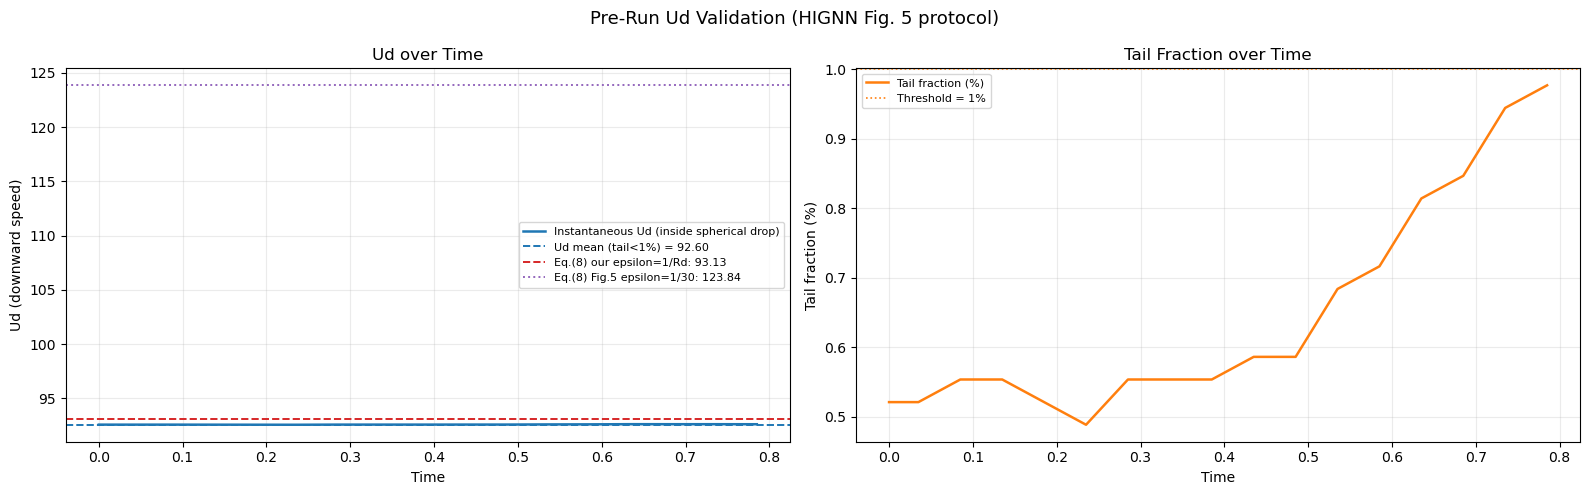

In [17]:
# Cell 6: Pre-Run Fig. 5 Ud Validation (tail < 1%)

@torch.no_grad()
def compute_tail_fraction_and_mask(pos, drop_radius):
    center = pos.mean(dim=0, keepdim=True)
    radial = torch.linalg.norm(pos - center, dim=1)
    tail_mask = radial > drop_radius
    tail_fraction = tail_mask.float().mean().item()
    return tail_fraction, tail_mask

@torch.no_grad()
def estimate_ud_initial_stage(pos0):
    """Estimate U_d using paper protocol: initial stage while tail fraction < 1%."""
    pos = pos0.clone()
    t = 0.0
    dt = DT_INITIAL

    attempted_steps = 0
    accepted_steps = 0
    rejected_steps = 0

    initial_center = pos0.mean(dim=0, keepdim=True)
    initial_radial = torch.linalg.norm(pos0 - initial_center, dim=1)
    # Robust spherical-drop radius from initial cloud (keeps initial tail under 1%).
    drop_radius_ref = max(R_DROP, torch.quantile(initial_radial, 0.995).item())

    time_samples = []
    ud_samples = []
    tail_samples = []

    ud_weighted_sum = 0.0
    ud_weight = 0.0

    tail_crossed = False
    tail_cross_time = None

    while t < UD_MAX_TIME - 1e-12:
        tail_fraction, tail_mask = compute_tail_fraction_and_mask(pos, drop_radius_ref)
        in_drop = ~tail_mask

        vel = compute_velocity(pos)[:, :3]
        if in_drop.any().item():
            ud_inst = (-vel[in_drop, 2]).mean().item()  # downward speed as positive
        else:
            ud_inst = (-vel[:, 2]).mean().item()

        if tail_fraction >= UD_TAIL_THRESHOLD and len(ud_samples) > 0:
            tail_crossed = True
            tail_cross_time = t
            break

        time_samples.append(t)
        ud_samples.append(ud_inst)
        tail_samples.append(tail_fraction)

        local_dt = min(dt, UD_MAX_TIME - t)
        next_pos, err_norm, dt_next, accepted = rkf45_adaptive_step(pos, local_dt)
        attempted_steps += 1

        if accepted:
            pos = next_pos
            t += local_dt
            dt = dt_next
            accepted_steps += 1

            ud_weighted_sum += ud_inst * local_dt
            ud_weight += local_dt

            if accepted_steps % UD_PRINT_EVERY == 0:
                print(
                    f"  Ud step {accepted_steps:4d}: t={t:7.3f}, dt={local_dt:7.5f}, "
                    f"Ud={ud_inst:8.4f}, tail={100.0 * tail_fraction:5.2f}%, err={err_norm:8.2e}"
                )
        else:
            rejected_steps += 1
            dt = dt_next
            if dt <= DT_MIN + 1e-12:
                print("  RKF45 hit DT_MIN during Ud validation; stopping early.")
                break

    assert len(ud_samples) > 0, \
        "Ud validation collected no samples. Relax tolerances or increase UD_MAX_TIME."

    ud_mean = float(ud_weighted_sum / ud_weight) if ud_weight > 0.0 else float(np.mean(ud_samples))

    return {
        "ud_mean": ud_mean,
        "drop_radius_ref": drop_radius_ref,
        "time_samples": np.array(time_samples, dtype=np.float64),
        "ud_samples": np.array(ud_samples, dtype=np.float64),
        "tail_samples": np.array(tail_samples, dtype=np.float64),
        "tail_crossed": tail_crossed,
        "tail_cross_time": tail_cross_time,
        "attempted_steps": attempted_steps,
        "accepted_steps": accepted_steps,
        "rejected_steps": rejected_steps,
        "final_time": t,
    }

ud_validation = estimate_ud_initial_stage(initial_positions)

epsilon_geom = 1.0 / R_DROP
phi_drop = N / (R_DROP ** 3)
ud_hr_our_setup = 1.0 + (6.0 / 5.0) * (N * epsilon_geom)

eps_fig5 = 1.0 / 30.0
ud_hr_fig5_epsilon = 1.0 + (6.0 / 5.0) * (N * eps_fig5)

print()
print("--- Pre-Run Ud Validation (Paper Protocol) ---")
print(f"N = {N}, R_DROP = {R_DROP:.1f}")
print(f"Geometric epsilon (a/Rd) = {epsilon_geom:.6f}, phi = {phi_drop:.6f}")
print(f"Reference spherical radius for tail test = {ud_validation['drop_radius_ref']:.4f}")
print(f"Ud mean from simulation (tail < 1%) = {ud_validation['ud_mean']:.4f}")
print(f"Eq. (8) HR Ud with our epsilon=1/R_DROP = {ud_hr_our_setup:.4f}")
print(f"Eq. (8) HR Ud with Fig.5 epsilon=1/30   = {ud_hr_fig5_epsilon:.4f}")
if ud_validation["tail_crossed"]:
    print(f"Tail threshold crossed at t = {ud_validation['tail_cross_time']:.3f}")
else:
    print(f"Tail threshold not crossed before t = {ud_validation['final_time']:.3f}")
print(
    f"Validation RKF stats: attempted={ud_validation['attempted_steps']}, "
    f"accepted={ud_validation['accepted_steps']}, rejected={ud_validation['rejected_steps']}"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left panel: Ud over time
ax1.plot(
    ud_validation["time_samples"],
    ud_validation["ud_samples"],
    color="tab:blue",
    lw=1.8,
    label="Instantaneous Ud (inside spherical drop)",
)
ax1.axhline(
    ud_validation["ud_mean"],
    color="tab:blue",
    ls="--",
    lw=1.4,
    label=f"Ud mean (tail<1%) = {ud_validation['ud_mean']:.2f}",
)
ax1.axhline(
    ud_hr_our_setup,
    color="tab:red",
    ls="--",
    lw=1.4,
    label=f"Eq.(8) our epsilon=1/Rd: {ud_hr_our_setup:.2f}",
)
ax1.axhline(
    ud_hr_fig5_epsilon,
    color="tab:purple",
    ls=":",
    lw=1.4,
    label=f"Eq.(8) Fig.5 epsilon=1/30: {ud_hr_fig5_epsilon:.2f}",
)
ax1.set_xlabel("Time")
ax1.set_ylabel("Ud (downward speed)")
ax1.set_title("Ud over Time")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.25)

# Right panel: Tail fraction over time
ax2.plot(
    ud_validation["time_samples"],
    100.0 * ud_validation["tail_samples"],
    color="tab:orange",
    lw=1.8,
    label="Tail fraction (%)",
)
ax2.axhline(100.0 * UD_TAIL_THRESHOLD, color="tab:orange", ls=":", lw=1.2,
            label=f"Threshold = {100.0 * UD_TAIL_THRESHOLD:.0f}%")
ax2.set_xlabel("Time")
ax2.set_ylabel("Tail fraction (%)")
ax2.set_title("Tail Fraction over Time")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)

fig.suptitle("Pre-Run Ud Validation (HIGNN Fig. 5 protocol)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'single_drop_ud_validation.png'), dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# Cell 7: Main Simulation Loop (Adaptive RKF45)

positions = initial_positions.clone()
current_time = 0.0
attempted_steps = 0
accepted_steps = 0
rejected_steps = 0
dt = DT_INITIAL

accepted_dt_hist = []
accepted_err_hist = []
max_vel_times = []
max_vel_hist = []

# Snapshot storage: list of (t, positions_cpu, vel_magnitudes_cpu)
snapshots = []
next_snapshot_time = 0.0


def take_snapshot(t, pos):
    """Store a snapshot of positions and velocity magnitudes."""
    vel = compute_velocity(pos)
    vel_mag = torch.linalg.norm(vel[:, :3], dim=1).cpu().numpy()
    pos_cpu = pos.detach().cpu().numpy().copy()
    snapshots.append((t, pos_cpu, vel_mag))
    print(f"  Snapshot at t={t:.3f}: mean |v|={vel_mag.mean():.4f}, max |v|={vel_mag.max():.4f}")


print(
    f"Starting main simulation: T_FINAL={T_FINAL}, "
    f"adaptive DT in [{DT_MIN}, {DT_MAX}], snapshots every {SNAPSHOT_INTERVAL}"
)

# Take initial snapshot
take_snapshot(0.0, positions)
next_snapshot_time = SNAPSHOT_INTERVAL

sim_start = time.perf_counter()

with torch.no_grad():
    while current_time < T_FINAL - 1e-12:
        event_time = min(T_FINAL, next_snapshot_time)
        remaining = event_time - current_time

        if remaining <= 1e-12:
            if current_time >= next_snapshot_time - 1e-9:
                take_snapshot(current_time, positions)
                next_snapshot_time += SNAPSHOT_INTERVAL
                continue
            break

        local_dt = min(dt, remaining)

        step_start = time.perf_counter()
        next_pos, err_norm, dt_next, accepted = rkf45_adaptive_step(positions, local_dt)
        attempted_steps += 1
        step_wall = time.perf_counter() - step_start

        if accepted:
            # Track max particle velocity (displacement / dt)
            max_disp_vel = torch.max(torch.linalg.norm(next_pos - positions, dim=1)).item() / local_dt
            max_vel_times.append(current_time + local_dt)
            max_vel_hist.append(max_disp_vel)

            positions = next_pos
            current_time += local_dt
            accepted_steps += 1
            dt = dt_next

            accepted_dt_hist.append(local_dt)
            accepted_err_hist.append(err_norm)

            if current_time >= next_snapshot_time - 1e-9:
                take_snapshot(current_time, positions)
                next_snapshot_time += SNAPSHOT_INTERVAL

            if accepted_steps % 100 == 0:
                print(
                    f"Accepted {accepted_steps:5d} / {attempted_steps:5d} tries | "
                    f"t={current_time:8.3f}, dt={local_dt:7.5f}, "
                    f"err={err_norm:8.2e}, wall={step_wall:6.3f}s"
                )
            print(f"t={current_time:8.3f}")
        else:
            rejected_steps += 1
            dt = dt_next
            if rejected_steps % 50 == 0:
                print(
                    f"Rejected {rejected_steps:5d} steps at t={current_time:8.3f} | "
                    f"new dt={dt:7.5f}, err={err_norm:8.2e}"
                )
            if dt <= DT_MIN + 1e-12:
                print("RKF45 reached DT_MIN with rejected step. Stopping early.")
                break

sim_end = time.perf_counter()

print()
print(
    f"Simulation complete in {sim_end - sim_start:.1f}s | "
    f"attempted={attempted_steps}, accepted={accepted_steps}, rejected={rejected_steps}"
)
if accepted_dt_hist:
    print(
        f"Accepted dt stats: min={np.min(accepted_dt_hist):.5f}, "
        f"max={np.max(accepted_dt_hist):.5f}, median={np.median(accepted_dt_hist):.5f}"
    )
    print(f"Max accepted embedded error norm: {np.max(accepted_err_hist):.3e}")
print(f"Total snapshots: {len(snapshots)}")

Starting main simulation: T_FINAL=500.0, adaptive DT in [0.0005, 0.05], snapshots every 3.0
  Snapshot at t=0.000: mean |v|=92.6829, max |v|=115.5046


t=   0.010
t=   0.035
t=   0.085
t=   0.135
t=   0.185
t=   0.235
t=   0.285
t=   0.335
t=   0.385
t=   0.435
t=   0.485
t=   0.535
t=   0.585
t=   0.635
t=   0.685
t=   0.735
t=   0.785
t=   0.835
t=   0.885
t=   0.935
t=   0.985
t=   1.035
t=   1.085
t=   1.135
t=   1.185
t=   1.235
t=   1.285
t=   1.335
t=   1.385
t=   1.435
t=   1.485
t=   1.535
t=   1.585
t=   1.635
t=   1.685
t=   1.735
t=   1.785
t=   1.835
t=   1.885
t=   1.935
t=   1.985
t=   2.035
t=   2.085
t=   2.135
t=   2.185
t=   2.235
t=   2.285
t=   2.335
t=   2.385
t=   2.435
t=   2.485
t=   2.535
t=   2.585
t=   2.635
t=   2.685
t=   2.735
t=   2.785
t=   2.835
t=   2.885
t=   2.935
t=   2.985
  Snapshot at t=3.000: mean |v|=92.6404, max |v|=116.3902
t=   3.000
t=   3.038
t=   3.088
t=   3.138
t=   3.188
t=   3.238
t=   3.288
t=   3.338
t=   3.388
t=   3.438
t=   3.488
t=   3.538
t=   3.588
t=   3.638
t=   3.688
t=   3.738
t=   3.788
t=   3.838
t=   3.888
t=   3.938
t=   3.988
t=   4.038
t=   4.088
t=   4.138
t=   4.

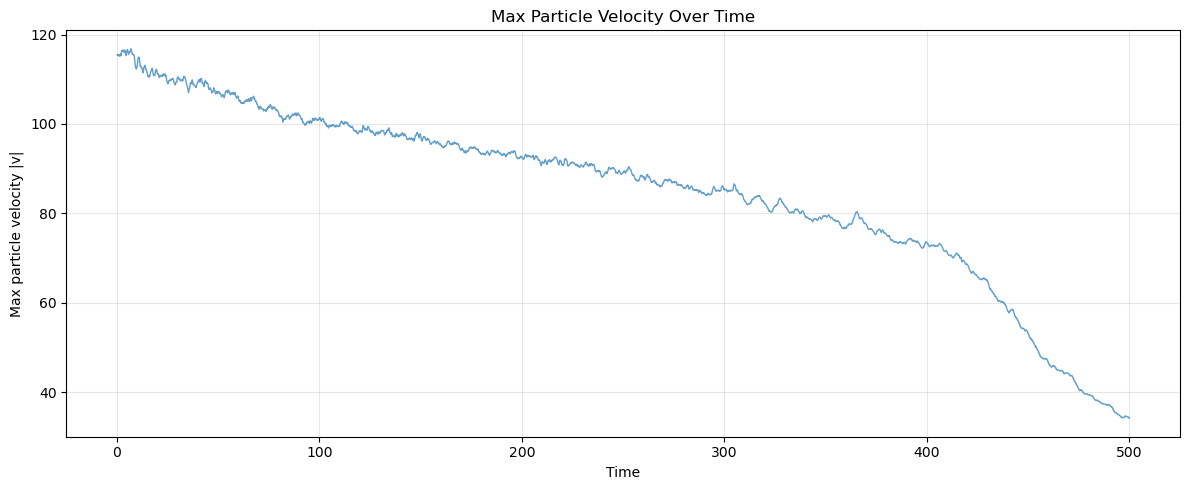

Total samples: 10006
Peak max velocity: 116.8178 at t=6.881
Final max velocity: 34.1475


In [19]:
# Cell 7b: Plot Max Particle Velocity Over Time

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(max_vel_times, max_vel_hist, color="tab:blue", lw=1.0, alpha=0.7)
ax.set_xlabel("Time")
ax.set_ylabel("Max particle velocity |v|")
ax.set_title("Max Particle Velocity Over Time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'single_drop_max_velocity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Total samples: {len(max_vel_hist)}")
if max_vel_hist:
    print(f"Peak max velocity: {np.max(max_vel_hist):.4f} at t={max_vel_times[np.argmax(max_vel_hist)]:.3f}")
    print(f"Final max velocity: {max_vel_hist[-1]:.4f}")

In [20]:

def find_closest_snapshots(target_times):
    result = []
    snap_times = np.array([s[0] for s in snapshots])
    for t in target_times:
        idx = np.argmin(np.abs(snap_times - t))
        result.append(snapshots[idx])
    return result

import pickle

# with open("sedimentation_torus_snapshots.pkl", "wb") as f:
#     pickle.dump(snapshots, f, protocol=pickle.HIGHEST_PROTOCOL)


# with open("sedimentation_torus_snapshots.pkl", "rb") as f:
#     snapshots = pickle.load(f)


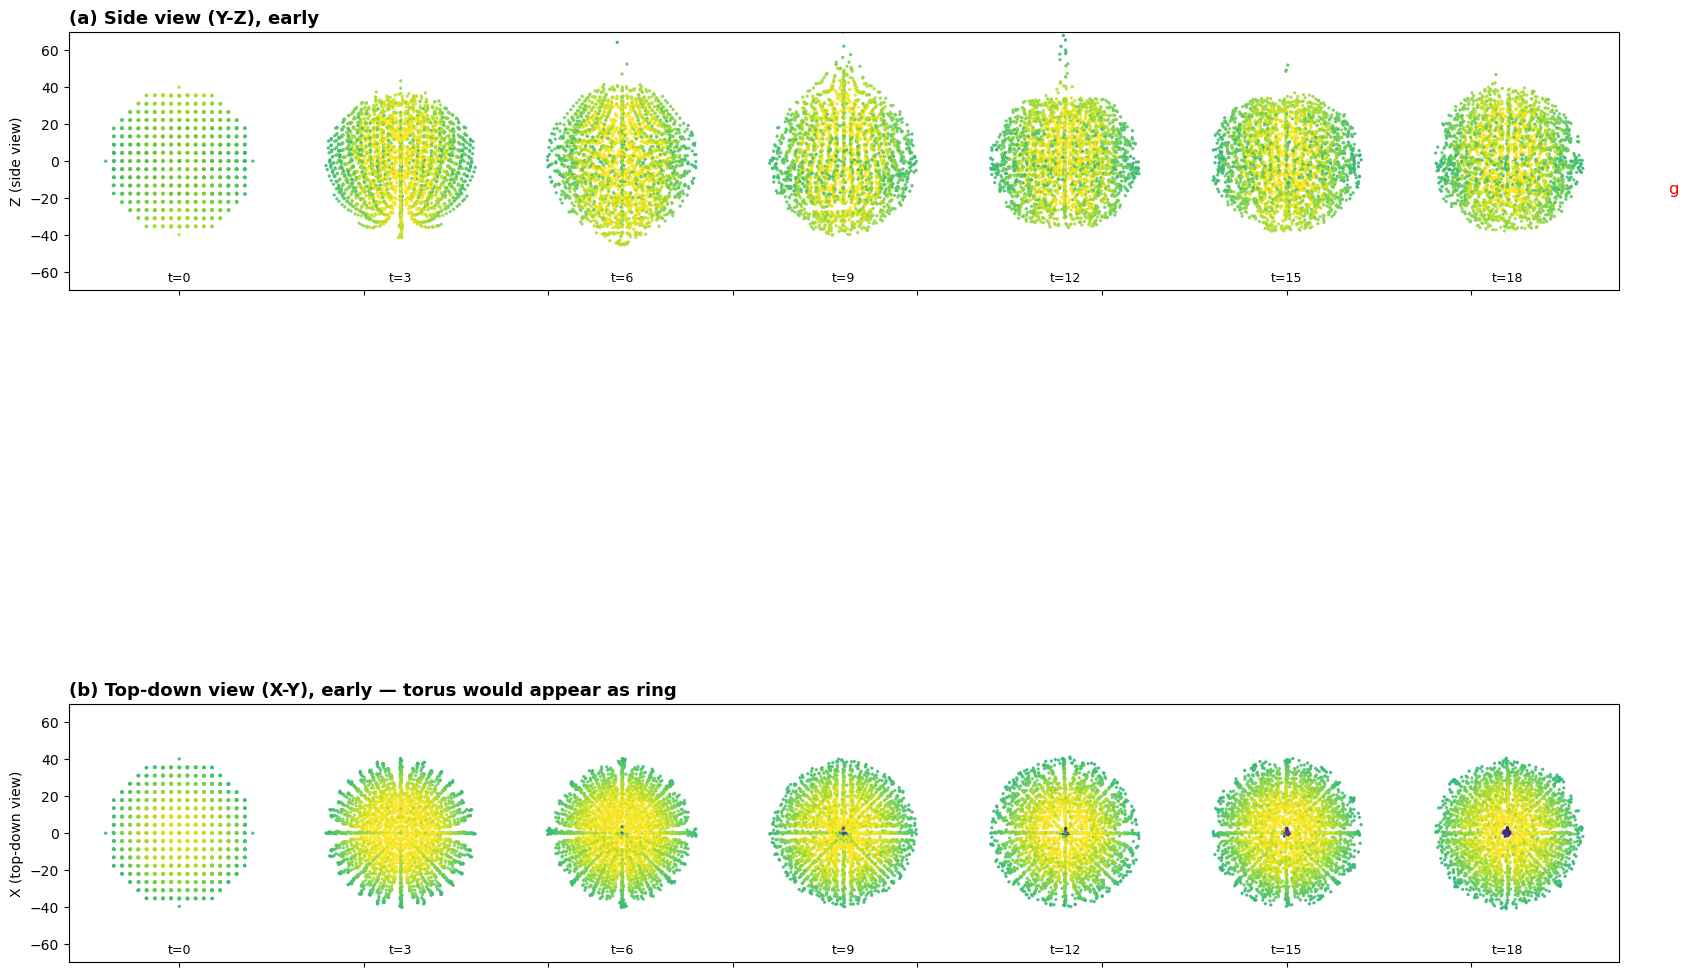

In [21]:
# Cell 8: Create Fig. 3 — Side + Top-Down Views
save_path=os.path.join(project_root, 'single_drop_fig3.png')


"""Reproduce Fig. 3 from Ma & Pan (2024).

Three rows:
(a) Y-Z side view, t=0 to t=18  (early deformation)
(b) X-Y top-down view, t=0 to t=18  (shows torus ring if forming)
(c) Y-Z side view, t=80 to t=98 (late stage)
"""
early_times = np.arange(0, 19, 3)   # [0, 3, 6, 9, 12, 15, 18]

def find_closest_snapshots(target_times):
    result = []
    snap_times = np.array([s[0] for s in snapshots])
    for t in target_times:
        idx = np.argmin(np.abs(snap_times - t))
        result.append(snapshots[idx])
    return result

early_snaps = find_closest_snapshots(early_times)

# Global velocity range
all_vel = np.concatenate([s[2] for s in snapshots])
vmin, vmax = 0, np.percentile(all_vel, 99)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = cm.viridis

fig, axes = plt.subplots(2, 1, figsize=(20, 16))
shift = R_DROP * 3.0

# --- Panel (a): Y-Z side view, early ---
ax = axes[0]
y_offset = 0.0
for i, (t, pos, vel_mag) in enumerate(early_snaps):
    med = np.median(pos, axis=0)
    y_c = pos[:, 1] - med[1] + y_offset
    z_c = pos[:, 2] - med[2]
    ax.scatter(y_c, z_c, c=vel_mag, cmap=cmap, norm=norm,
                s=2, alpha=0.8, rasterized=True)
    ax.text(y_offset, -67, f't={t:.0f}', ha='center', va='bottom', fontsize=9)
    y_offset += shift
ax.set_ylim(-70, 70)
ax.set_xlim(-shift * 0.5, y_offset - shift * 0.5)
ax.set_aspect('equal')
ax.set_ylabel('Z (side view)')
ax.set_title('(a) Side view (Y-Z), early', loc='left', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', labelbottom=False)
arrow_x = y_offset - shift * 0.3
ax.annotate('', xy=(arrow_x, -30), xytext=(arrow_x, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(arrow_x + 3, -15, 'g', color='red', fontsize=12, va='center')

# --- Panel (b): X-Y top-down view, early ---
ax = axes[1]
y_offset = 0.0
for i, (t, pos, vel_mag) in enumerate(early_snaps):
    med = np.median(pos, axis=0)
    x_c = pos[:, 0] - med[0]
    y_c = pos[:, 1] - med[1] + y_offset
    ax.scatter(y_c, x_c, c=vel_mag, cmap=cmap, norm=norm,
                s=2, alpha=0.8, rasterized=True)
    ax.text(y_offset, -67, f't={t:.0f}', ha='center', va='bottom', fontsize=9)
    y_offset += shift
ax.set_ylim(-70, 70)
ax.set_xlim(-shift * 0.5, y_offset - shift * 0.5)
ax.set_aspect('equal')
ax.set_ylabel('X (top-down view)')
ax.set_title('(b) Top-down view (X-Y), early — torus would appear as ring',
                loc='left', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', labelbottom=False)

## Late Stage

### Y-Z Side View

In [22]:
late_times = np.arange(400, 500, 20)
publication_dpi = 1000
publication_shift = R_DROP * 7.0
side_view_shift = R_DROP * 8.5
publication_dir = os.path.join(project_root, 'figures')
assert os.path.isdir(publication_dir)
side_view_pdf = os.path.join(publication_dir, 'single_drop_side_view_late.pdf')
top_down_pdf = os.path.join(publication_dir, 'single_drop_top_down_late.pdf')


def format_publication_axis(ax):
    ax.set_xticks([])
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)


Figure saved to /mnt/ffs24/home/khanmd/pinn-stokes/figures/single_drop_side_view_late.pdf


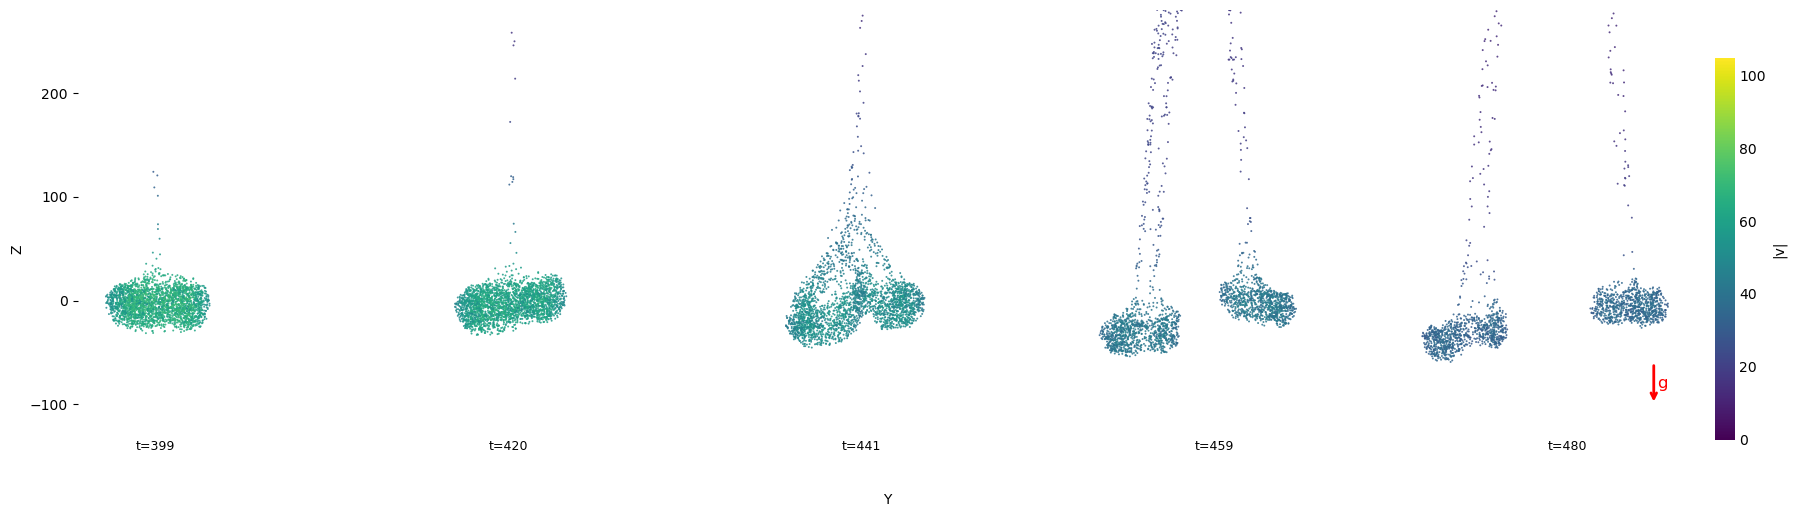

In [23]:
# --- Y-Z side view, late ---
late_snaps = find_closest_snapshots(late_times)
shift = side_view_shift

fig, ax = plt.subplots(figsize=(20, 7))

y_offset = 0.0
x_min, x_max = np.inf, -np.inf
for t, pos, vel_mag in late_snaps:
    med = np.median(pos, axis=0)
    y_c = pos[:, 1] + y_offset - med[1]
    z_c = pos[:, 2] - med[2]
    ax.scatter(
        y_c,
        z_c,
        c=vel_mag,
        cmap=cmap,
        norm=norm,
        s=2,
        alpha=0.85,
        rasterized=True,
        linewidths=0,
    )
    ax.text(y_offset, -147, f't={t:.0f}', ha='center', va='bottom', fontsize=9)
    x_min = min(x_min, float(np.min(y_c)))
    x_max = max(x_max, float(np.max(y_c)))
    y_offset += shift

ax.set_ylim(-180, 280)
ax.set_xlim(x_min - shift * 0.08, x_max + shift * 0.08)
ax.set_aspect('equal')
ax.set_xlabel('Y')
ax.set_ylabel('Z')
format_publication_axis(ax)

arrow_x = ax.get_xlim()[1] - shift * 0.12
ax.annotate('', xy=(arrow_x, -100), xytext=(arrow_x, -60),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(arrow_x + 3, -80, 'g', color='red', fontsize=12, va='center', clip_on=True)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.01, label='|v|')
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)
plt.tight_layout(pad=0.2)

fig.savefig(side_view_pdf, dpi=publication_dpi, bbox_inches='tight', pad_inches=0.02)
print(f'Figure saved to {side_view_pdf}')
plt.show()


## X-Y: Top-down View

Figure saved to /mnt/ffs24/home/khanmd/pinn-stokes/figures/single_drop_top_down_late.pdf


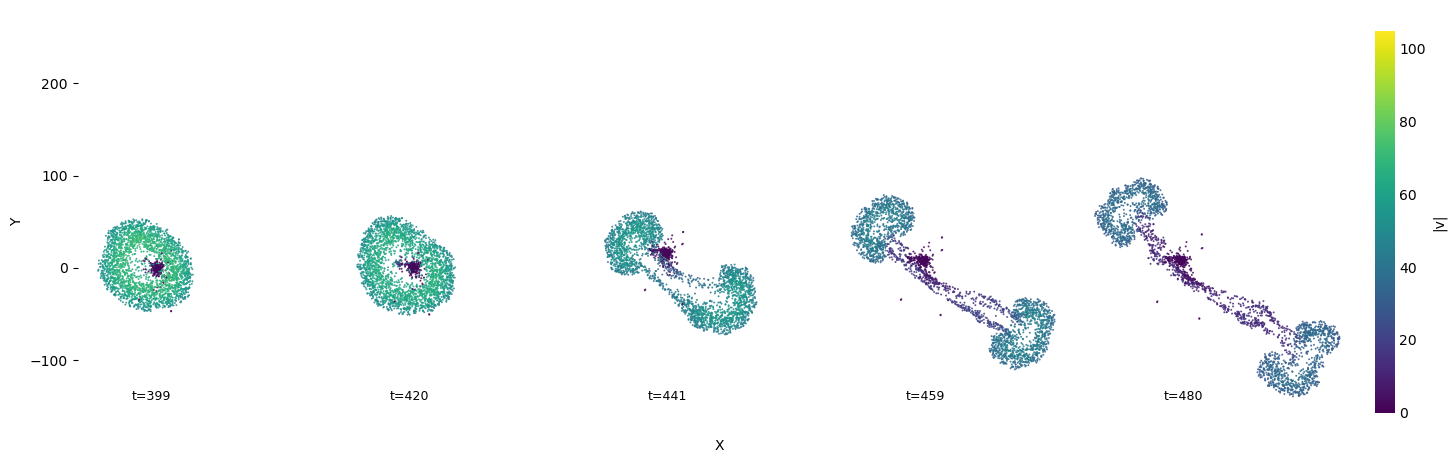

In [24]:
# --- X-Y top-down view, late ---
late_snaps = find_closest_snapshots(late_times)
shift = publication_shift

fig, ax = plt.subplots(figsize=(16, 7))

y_offset = 0.0
x_min, x_max = np.inf, -np.inf
for t, pos, vel_mag in late_snaps:
    med = np.median(pos, axis=0)
    x_c = pos[:, 0] + y_offset - med[0]
    y_c = pos[:, 1] - med[1]
    ax.scatter(
        x_c,
        y_c,
        c=vel_mag,
        cmap=cmap,
        norm=norm,
        s=2,
        alpha=0.85,
        rasterized=True,
        linewidths=0,
    )
    ax.text(y_offset, -147, f't={t:.0f}', ha='center', va='bottom', fontsize=9)
    x_min = min(x_min, float(np.min(x_c)))
    x_max = max(x_max, float(np.max(x_c)))
    y_offset += shift

ax.set_ylim(-180, 280)
ax.set_xlim(x_min - shift * 0.08, x_max + shift * 0.08)
ax.set_aspect('equal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
format_publication_axis(ax)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.01, label='|v|')
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)
plt.tight_layout(pad=0.2)

fig.savefig(top_down_pdf, dpi=publication_dpi, bbox_inches='tight', pad_inches=0.02)
print(f'Figure saved to {top_down_pdf}')
plt.show()


Saved storyboard to /mnt/ffs24/home/khanmd/pinn-stokes/figures/single_drop_storyboard_late.png
Saved storyboard to /mnt/ffs24/home/khanmd/pinn-stokes/figures/single_drop_storyboard_late.pdf
Used embedded late-view outputs because snapshots is not defined in this kernel.


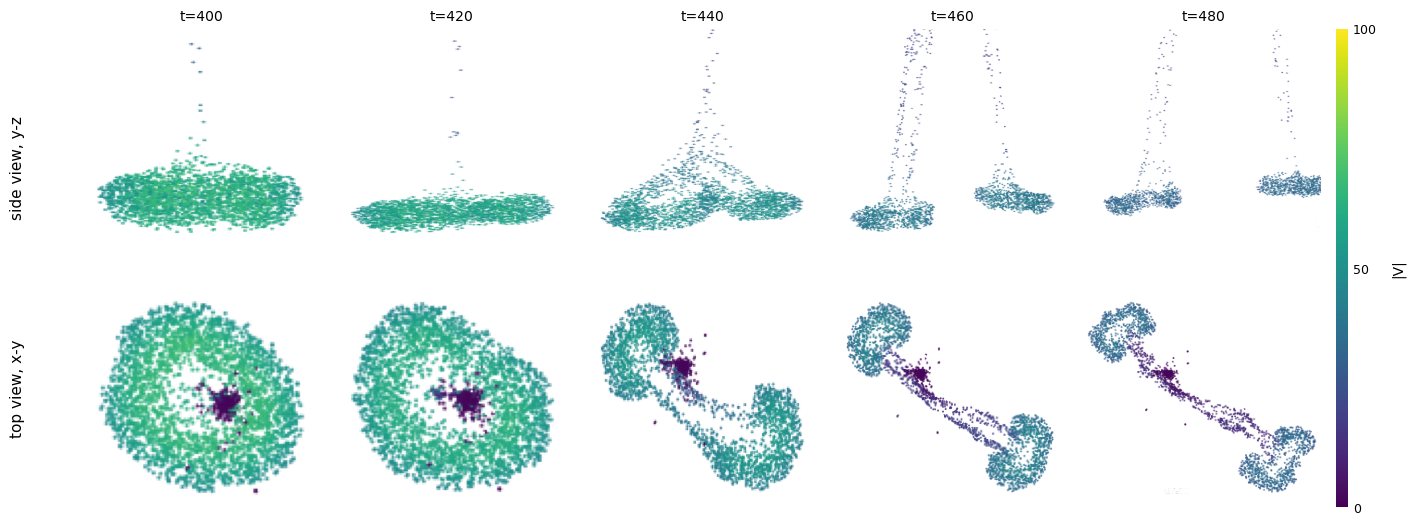

In [1]:
# Cell 8c: Late-stage sedimentation storyboard (2 x 5 panels)

import base64
import io
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

story_times = np.array([400, 420, 440, 460, 480], dtype=float)
story_labels = [f"t={int(t)}" for t in story_times]

try:
    publication_dir
except NameError:
    try:
        project_root
    except NameError:
        cwd = os.getcwd()
        project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'experiments' else cwd
    publication_dir = os.path.join(project_root, 'figures')
assert os.path.isdir(publication_dir), f'Missing figures directory: {publication_dir}'

storyboard_png = os.path.join(publication_dir, 'single_drop_storyboard_late.png')
storyboard_pdf = os.path.join(publication_dir, 'single_drop_storyboard_late.pdf')


def _make_storyboard_canvas():
    fig = plt.figure(figsize=(14.2, 5.8))
    gs = fig.add_gridspec(
        2,
        6,
        left=0.075,
        right=0.965,
        top=0.90,
        bottom=0.075,
        wspace=0.08,
        hspace=0.18,
        width_ratios=[1, 1, 1, 1, 1, 0.05],
    )
    axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(5)] for row in range(2)])
    cax = fig.add_subplot(gs[:, 5])
    return fig, axes, cax


def _clean_panel_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def _add_story_labels_and_gravity(fig, axes):
    fig.text(0.028, 0.66, 'side view, y-z', rotation=90, ha='center', va='center', fontsize=11)
    fig.text(0.028, 0.28, 'top view, x-y', rotation=90, ha='center', va='center', fontsize=11)


def _closest_snapshots(snapshots_in, target_times):
    snap_times = np.array([s[0] for s in snapshots_in])
    return [snapshots_in[int(np.argmin(np.abs(snap_times - target)))] for target in target_times]


def _limits_from_coords(coord_sets, pad_frac=0.08):
    xs = np.concatenate([xy[0] for xy in coord_sets])
    ys = np.concatenate([xy[1] for xy in coord_sets])
    x0, x1 = np.percentile(xs, [0.2, 99.8])
    y0, y1 = np.percentile(ys, [0.2, 99.8])
    dx = max(x1 - x0, 1.0)
    dy = max(y1 - y0, 1.0)
    return (x0 - pad_frac * dx, x1 + pad_frac * dx), (y0 - pad_frac * dy, y1 + pad_frac * dy)


def _plot_storyboard_from_snapshots():
    late_snaps = _closest_snapshots(snapshots, story_times)
    used_times = [float(s[0]) for s in late_snaps]

    story_cmap = cm.viridis
    all_vel = np.concatenate([s[2] for s in snapshots])
    story_norm = Normalize(vmin=0.0, vmax=float(np.percentile(all_vel, 99)))

    side_coords = []
    top_coords = []
    for _, pos, _ in late_snaps:
        center = np.median(pos, axis=0)
        side_coords.append((pos[:, 1] - center[1], pos[:, 2] - center[2]))
        top_coords.append((pos[:, 0] - center[0], pos[:, 1] - center[1]))

    side_xlim, side_ylim = _limits_from_coords(side_coords)
    top_xlim, top_ylim = _limits_from_coords(top_coords)

    fig, axes, cax = _make_storyboard_canvas()

    for col, (t, pos, vel_mag) in enumerate(late_snaps):
        center = np.median(pos, axis=0)
        y_side = pos[:, 1] - center[1]
        z_side = pos[:, 2] - center[2]
        x_top = pos[:, 0] - center[0]
        y_top = pos[:, 1] - center[1]

        ax = axes[0, col]
        ax.scatter(
            y_side,
            z_side,
            c=vel_mag,
            cmap=story_cmap,
            norm=story_norm,
            s=2.8,
            alpha=0.88,
            rasterized=True,
            linewidths=0,
        )
        ax.set_xlim(*side_xlim)
        ax.set_ylim(*side_ylim)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(story_labels[col], fontsize=10, pad=6)
        _clean_panel_axis(ax)

        ax = axes[1, col]
        ax.scatter(
            x_top,
            y_top,
            c=vel_mag,
            cmap=story_cmap,
            norm=story_norm,
            s=2.8,
            alpha=0.88,
            rasterized=True,
            linewidths=0,
        )
        ax.set_xlim(*top_xlim)
        ax.set_ylim(*top_ylim)
        ax.set_aspect('equal', adjustable='box')
        _clean_panel_axis(ax)

    _add_story_labels_and_gravity(fig, axes)

    sm = cm.ScalarMappable(norm=story_norm, cmap=story_cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('|V|', rotation=90, labelpad=10)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(length=0, labelsize=9)

    fig.savefig(storyboard_png, dpi=450, bbox_inches='tight', pad_inches=0.03)
    fig.savefig(storyboard_pdf, dpi=450, bbox_inches='tight', pad_inches=0.03)
    print(f"Saved storyboard to {storyboard_png}")
    print(f"Saved storyboard to {storyboard_pdf}")
    print('Snapshot times used:', ', '.join(f'{t:.0f}' for t in used_times))
    plt.show()


def _extract_late_view_image_outputs():
    """Fallback used only when the live notebook no longer has snapshots in memory."""
    notebook_path = Path('single_drop_sedimentation_executed.ipynb')
    if not notebook_path.exists():
        notebook_path = Path('experiments/single_drop_sedimentation_executed.ipynb')
    assert notebook_path.exists(), 'Could not find this notebook to read embedded late-view outputs.'

    nb_data = json.loads(notebook_path.read_text())
    images = {}
    for cell in nb_data.get('cells', []):
        src = ''.join(cell.get('source', []))
        if 'Cell 8c: Late-stage sedimentation storyboard' in src:
            continue
        if '# --- Y-Z side view, late ---' in src:
            key = 'side'
        elif '# --- X-Y top-down view, late ---' in src:
            key = 'top'
        else:
            continue
        for output in cell.get('outputs', []):
            data = output.get('data', {})
            if 'image/png' not in data:
                continue
            raw = data['image/png']
            if isinstance(raw, list):
                raw = ''.join(raw)
            images[key] = plt.imread(io.BytesIO(base64.b64decode(raw)), format='png')
            break
    assert {'side', 'top'} <= set(images), 'Embedded side/top late-view outputs were not found.'
    return images


def _remove_old_text_and_arrows(panel):
    cleaned = panel.copy()
    rgb = cleaned[..., :3]
    black_or_gray_text = (rgb.mean(axis=2) < 0.78) & ((rgb.max(axis=2) - rgb.min(axis=2)) < 0.10)
    red_arrow = (rgb[..., 0] > 0.45) & (rgb[..., 0] - np.maximum(rgb[..., 1], rgb[..., 2]) > 0.12)
    cleaned[black_or_gray_text | red_arrow, :3] = 1.0
    if cleaned.shape[-1] == 4:
        cleaned[black_or_gray_text | red_arrow, 3] = 1.0
    return cleaned


def _tighten_to_particles(panel, pad_frac=0.08):
    rgb = panel[..., :3]
    saturation = rgb.max(axis=2) - rgb.min(axis=2)
    colored_particles = (saturation > 0.08) & (rgb.min(axis=2) < 0.96)
    ys, xs = np.where(colored_particles)
    if len(xs) == 0 or len(ys) == 0:
        return panel
    pad_x = max(6, int((xs.max() - xs.min() + 1) * pad_frac))
    pad_y = max(6, int((ys.max() - ys.min() + 1) * pad_frac))
    x0 = max(int(xs.min()) - pad_x, 0)
    x1 = min(int(xs.max()) + pad_x + 1, panel.shape[1])
    y0 = max(int(ys.min()) - pad_y, 0)
    y1 = min(int(ys.max()) + pad_y + 1, panel.shape[0])
    return panel[y0:y1, x0:x1]


def _crop_embedded_row(image, row_kind, panel_count=5):
    h, w = image.shape[:2]
    if row_kind == 'side':
        x0, x1 = int(0.055 * w), int(0.925 * w)
        y0, y1 = int(0.025 * h), int(0.890 * h)
    else:
        x0, x1 = int(0.055 * w), int(0.925 * w)
        y0, y1 = int(0.035 * h), int(0.940 * h)

    row = image[y0:y1, x0:x1]
    width = row.shape[1]
    panels = []
    for i in range(panel_count):
        a = int(i * width / panel_count)
        b = int((i + 1) * width / panel_count)
        panel = _remove_old_text_and_arrows(row[:, a:b])
        panels.append(_tighten_to_particles(panel))
    return panels


def _plot_storyboard_from_embedded_outputs():
    images = _extract_late_view_image_outputs()
    side_panels = _crop_embedded_row(images['side'], 'side')
    top_panels = _crop_embedded_row(images['top'], 'top')

    fig, axes, cax = _make_storyboard_canvas()
    for col in range(5):
        for row, panels in enumerate((side_panels, top_panels)):
            ax = axes[row, col]
            ax.imshow(panels[col], aspect='auto')
            _clean_panel_axis(ax)
        axes[0, col].set_title(story_labels[col], fontsize=10, pad=6)

    _add_story_labels_and_gravity(fig, axes)

    sm = cm.ScalarMappable(norm=Normalize(vmin=0.0, vmax=100.0), cmap=cm.viridis)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('|V|', rotation=90, labelpad=10)
    cbar.set_ticks([0, 50, 100])
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(length=0, labelsize=9)

    fig.savefig(storyboard_png, dpi=450, bbox_inches='tight', pad_inches=0.03)
    fig.savefig(storyboard_pdf, dpi=450, bbox_inches='tight', pad_inches=0.03)
    print(f"Saved storyboard to {storyboard_png}")
    print(f"Saved storyboard to {storyboard_pdf}")
    print('Used embedded late-view outputs because snapshots is not defined in this kernel.')
    plt.show()


if 'snapshots' in globals():
    _plot_storyboard_from_snapshots()
else:
    _plot_storyboard_from_embedded_outputs()




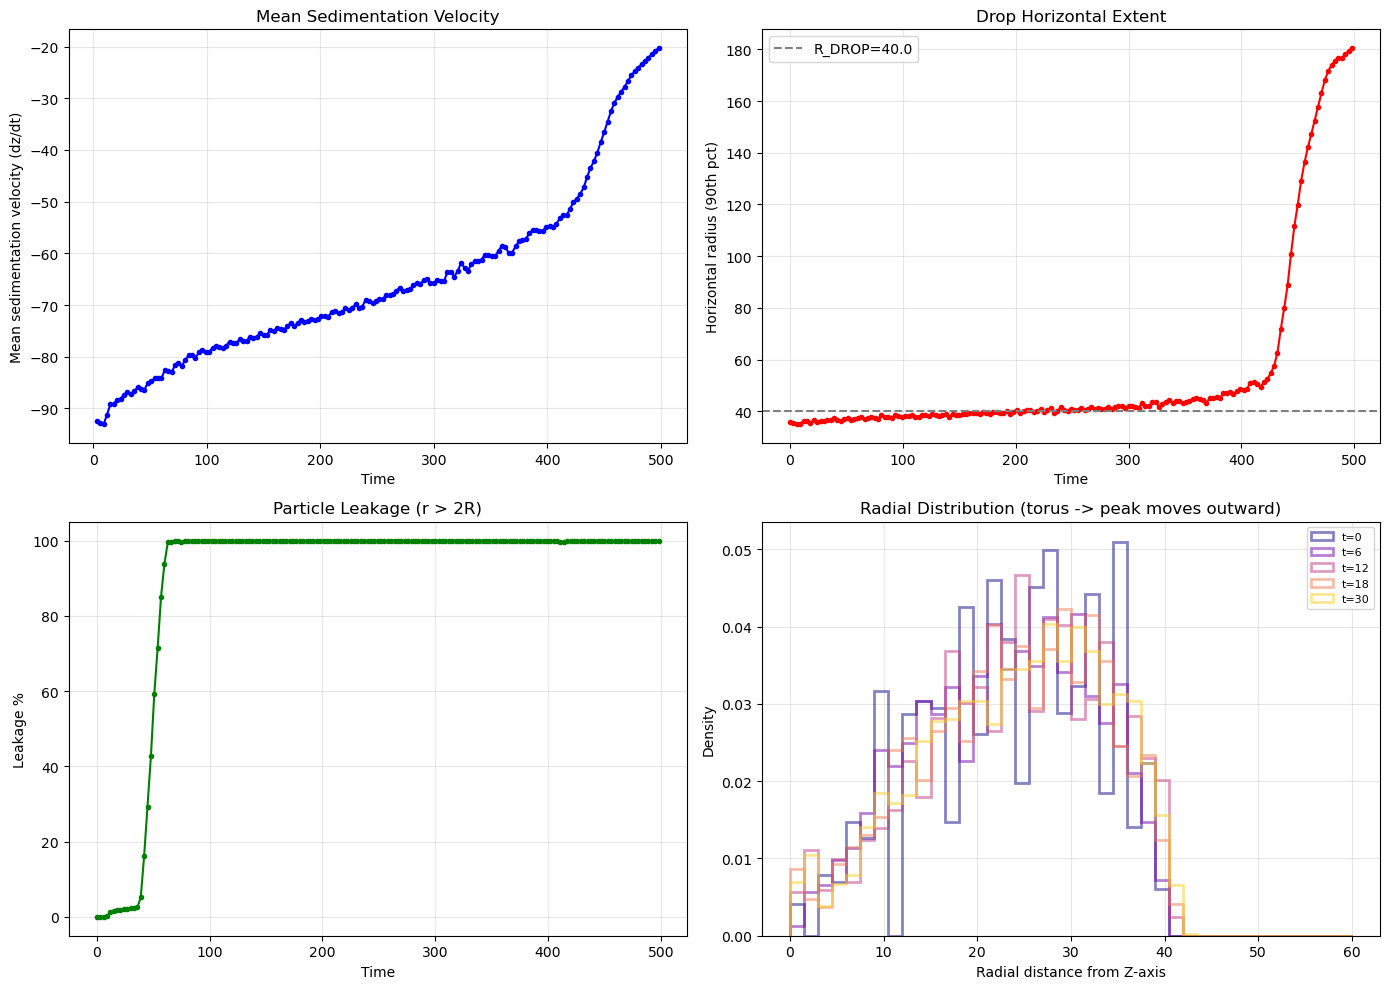


--- Eq. (8) / Ud Checks ---
N = 3071, R_DROP = 40.0, epsilon=a/Rd = 0.025000, phi = 0.047984
Pre-run Ud mean (tail < 1%): 92.6012
Eq. (8) HR Ud with our epsilon=1/R_DROP: 93.1300
Eq. (8) HR Ud with Fig.5 epsilon=1/30:   123.8400
Initial snapshot mean |v|: 92.6829
Tail crossed 1% at t=0.835 during pre-run validation.


In [25]:
# Cell 9: Diagnostics

snap_times = np.array([s[0] for s in snapshots])
mean_vel = np.array([s[2].mean() for s in snapshots])

# Compute mean z-velocity from position differences
mean_sed_vel = []
for i in range(1, len(snapshots)):
    dt_snap = snapshots[i][0] - snapshots[i - 1][0]
    if dt_snap > 0:
        dz = snapshots[i][1][:, 2].mean() - snapshots[i - 1][1][:, 2].mean()
        mean_sed_vel.append(dz / dt_snap)
    else:
        mean_sed_vel.append(0.0)
mean_sed_vel = np.array(mean_sed_vel)

# Drop horizontal radius over time (use median center, robust to stragglers)
horiz_radius = []
for t, pos, vel_mag in snapshots:
    center_xy = np.median(pos[:, :2], axis=0)
    r_xy = np.linalg.norm(pos[:, :2] - center_xy, axis=1)
    horiz_radius.append(np.percentile(r_xy, 90))
horiz_radius = np.array(horiz_radius)

# Leakage: fraction of particles far from center of mass
leak_pct = []
for t, pos, vel_mag in snapshots:
    com = pos.mean(axis=0)
    r = np.linalg.norm(pos - com, axis=1)
    leak_pct.append(100.0 * np.mean(r > 2.0 * R_DROP))
leak_pct = np.array(leak_pct)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Mean sedimentation velocity
axes[0, 0].plot(snap_times[1:], mean_sed_vel, 'b-o', markersize=3)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Mean sedimentation velocity (dz/dt)')
axes[0, 0].set_title('Mean Sedimentation Velocity')
axes[0, 0].grid(True, alpha=0.3)

# (b) Horizontal radius
axes[0, 1].plot(snap_times, horiz_radius, 'r-o', markersize=3)
axes[0, 1].axhline(R_DROP, color='gray', linestyle='--', label=f'R_DROP={R_DROP}')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Horizontal radius (90th pct)')
axes[0, 1].set_title('Drop Horizontal Extent')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Leakage
axes[1, 0].plot(snap_times, leak_pct, 'g-o', markersize=3)
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Leakage %')
axes[1, 0].set_title('Particle Leakage (r > 2R)')
axes[1, 0].grid(True, alpha=0.3)

# (d) Radial distribution at key times - bimodal = torus formation
ax = axes[1, 1]
key_times = [0, 6, 12, 18, 30]
colors_rd = plt.cm.plasma(np.linspace(0, 0.9, len(key_times)))
snap_t_arr = np.array([s[0] for s in snapshots])
for kt, clr in zip(key_times, colors_rd):
    idx = np.argmin(np.abs(snap_t_arr - kt))
    t, pos, _ = snapshots[idx]
    med_xy = np.median(pos[:, :2], axis=0)
    r_xy = np.linalg.norm(pos[:, :2] - med_xy, axis=1)
    ax.hist(
        r_xy,
        bins=40,
        range=(0, 60),
        alpha=0.5,
        color=clr,
        label=f't={t:.0f}',
        density=True,
        histtype='step',
        linewidth=2,
    )
ax.set_xlabel('Radial distance from Z-axis')
ax.set_ylabel('Density')
ax.set_title('Radial Distribution (torus -> peak moves outward)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'single_drop_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()

print()
print("--- Eq. (8) / Ud Checks ---")
print(f"N = {N}, R_DROP = {R_DROP:.1f}, epsilon=a/Rd = {epsilon_geom:.6f}, phi = {phi_drop:.6f}")
print(f"Pre-run Ud mean (tail < 1%): {ud_validation['ud_mean']:.4f}")
print(f"Eq. (8) HR Ud with our epsilon=1/R_DROP: {ud_hr_our_setup:.4f}")
print(f"Eq. (8) HR Ud with Fig.5 epsilon=1/30:   {ud_hr_fig5_epsilon:.4f}")
print(f"Initial snapshot mean |v|: {mean_vel[0]:.4f}")
if ud_validation["tail_crossed"]:
    print(f"Tail crossed 1% at t={ud_validation['tail_cross_time']:.3f} during pre-run validation.")
else:
    print("Tail did not cross 1% before UD_MAX_TIME during pre-run validation.")
